# Descriptive analysis of the ENMV cross-inoculation matrix

This notebook reproduces the descriptive analyses used before fitting the mechanistic model.



## Imports and output directory

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform
from scipy.special import expit
from scipy.optimize import minimize
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap, Normalize

# Output directory
OUT = "../figures_paper" if os.path.basename(os.getcwd()) == "notebooks" else "figures_paper"
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
})


## Aggregated cross-inoculation data and color convention

In [2]:
# Host and source labels
HOSTS = ["CH", "LA", "SA", "SO", "ZI"]
targets = HOSTS
sources = ["CL"] + HOSTS
labels = sources

# Same color convention as in the MCMC notebook
colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))
label_to_color = {lab: colors[i] for i, lab in enumerate(labels)}

# Aggregated success counts from Table 1
success = pd.DataFrame(
    [
        [19, 16, 21,  0,  4],  # CL
        [95, 74, 56,  0, 15],  # CH
        [95, 69, 53,  5, 16],  # LA
        [96, 67, 51,  2, 14],  # SA
        [75, 77, 59, 96, 77],  # SO
        [90, 85, 45, 82, 89],  # ZI
    ],
    index=sources,
    columns=targets,
)

# Number of inoculated plants
trials = pd.DataFrame(
    [
        [20, 20, 40, 60, 20],  # CL
        [96, 96, 96, 96, 96],  # CH
        [96, 96, 96, 96, 96],  # LA
        [96, 96, 96, 96, 96],  # SA
        [96, 96, 96, 96, 96],  # SO
        [96, 96, 96, 96, 96],  # ZI
    ],
    index=sources,
    columns=targets,
)

rates = success / trials

display(success)
display(trials)
display(rates.round(3))


,CH,LA,SA,SO,ZI
CL,19,16,21,0,4
CH,95,74,56,0,15
LA,95,69,53,5,16
SA,96,67,51,2,14
SO,75,77,59,96,77
ZI,90,85,45,82,89


,CH,LA,SA,SO,ZI
CL,20,20,40,60,20
CH,96,96,96,96,96
LA,96,96,96,96,96
SA,96,96,96,96,96
SO,96,96,96,96,96
ZI,96,96,96,96,96


,CH,LA,SA,SO,ZI
CL,0.950,0.800,0.525,0.000,0.200
CH,0.990,0.771,0.583,0.000,0.156
LA,0.990,0.719,0.552,0.052,0.167
SA,1.000,0.698,0.531,0.021,0.146
SO,0.781,0.802,0.615,1.000,0.802
ZI,0.938,0.885,0.469,0.854,0.927


## Descriptive GLMs for source, target, and sympatric effects

In [3]:
# Long-format table for GLM analyses
rows = []
for source in sources:
    for target in targets:
        rows.append({
            "source": source,
            "target": target,
            "success": int(success.loc[source, target]),
            "failure": int(trials.loc[source, target] - success.loc[source, target]),
            "N": int(trials.loc[source, target]),
            "rate": float(rates.loc[source, target]),
            "evolved_source": int(source != "CL"),
            "sympatric": int(source == target) if source != "CL" else 0,
        })

df = pd.DataFrame(rows)
display(df.head())

# We fit the GLMs to evolved-source rows only, as in the manuscript.
evo = df[df["evolved_source"] == 1].copy().reset_index(drop=True)

def make_design_matrix(data, include_source=False, include_target=False, include_sympatric=False):
    """
    Build a treatment-coded design matrix.

    Baselines:
    - source baseline: CH
    - target baseline: CH
    """
    cols = [np.ones(len(data))]
    names = ["Intercept"]

    if include_source:
        for lev in ["LA", "SA", "SO", "ZI"]:  # baseline CH
            cols.append((data["source"].values == lev).astype(float))
            names.append(f"source[{lev}]")

    if include_target:
        for lev in ["LA", "SA", "SO", "ZI"]:  # baseline CH
            cols.append((data["target"].values == lev).astype(float))
            names.append(f"target[{lev}]")

    if include_sympatric:
        cols.append(data["sympatric"].values.astype(float))
        names.append("sympatric")

    return np.column_stack(cols), names


def fit_grouped_binomial_glm(y, n, X, names):
    """
    Fit a grouped-binomial logistic regression by maximum likelihood.

    The log-likelihood omits the binomial coefficients, which cancel in
    likelihood-ratio tests and deviance comparisons.
    """
    y = np.asarray(y, dtype=float)
    n = np.asarray(n, dtype=float)
    X = np.asarray(X, dtype=float)

    def neg_loglik(beta):
        eta = X @ beta
        # Stable negative log-likelihood for grouped binomial data:
        # -sum[y*eta - n*log(1+exp(eta))]
        return np.sum(n * np.logaddexp(0.0, eta) - y * eta)

    def grad_neg_loglik(beta):
        eta = X @ beta
        p = expit(eta)
        return X.T @ (n * p - y)

    res = minimize(
        neg_loglik,
        x0=np.zeros(X.shape[1]),
        jac=grad_neg_loglik,
        method="L-BFGS-B",
        options={"maxiter": 10000, "ftol": 1e-12, "gtol": 1e-8},
    )

    if not res.success:
        print("Warning: optimizer did not fully converge:", res.message)

    beta = res.x
    ll = -neg_loglik(beta)
    p = expit(X @ beta)

    return {
        "beta": beta,
        "coef_names": names,
        "llf": ll,
        "p": p,
        "df_model": X.shape[1] - 1,
        "n_params": X.shape[1],
        "success": res.success,
        "message": res.message,
    }


def saturated_loglik(y, n):
    """
    Saturated grouped-binomial log-likelihood, omitting binomial coefficients.
    Terms with y=0 or y=n are handled by convention 0 log 0 = 0.
    """
    y = np.asarray(y, dtype=float)
    n = np.asarray(n, dtype=float)
    p = np.divide(y, n, out=np.zeros_like(y), where=n > 0)
    out = np.zeros_like(p, dtype=float)

    mask1 = y > 0
    out[mask1] += y[mask1] * np.log(p[mask1])

    mask2 = y < n
    out[mask2] += (n[mask2] - y[mask2]) * np.log(1.0 - p[mask2])

    return float(np.sum(out))


y = evo["success"].values
n_trials = evo["N"].values
ll_sat = saturated_loglik(y, n_trials)

glm_specs = [
    ("intercept", dict(include_source=False, include_target=False, include_sympatric=False)),
    ("target", dict(include_source=False, include_target=True, include_sympatric=False)),
    ("source", dict(include_source=True, include_target=False, include_sympatric=False)),
    ("source + target", dict(include_source=True, include_target=True, include_sympatric=False)),
    ("source + target + sympatric", dict(include_source=True, include_target=True, include_sympatric=True)),
]

models = {}
for name, kwargs in glm_specs:
    X, names = make_design_matrix(evo, **kwargs)
    models[name] = fit_grouped_binomial_glm(y, n_trials, X, names)

for model in models.values():
    model["deviance"] = 2.0 * (ll_sat - model["llf"])
    model["AIC"] = 2.0 * model["n_params"] - 2.0 * model["llf"]

null_deviance = models["intercept"]["deviance"]

glm_summary = pd.DataFrame([
    {
        "model": name,
        "converged": model["success"],
        "df_model": model["df_model"],
        "n_params": model["n_params"],
        "deviance": model["deviance"],
        "AIC_no_binomial_constants": model["AIC"],
        "logLik_no_binomial_constants": model["llf"],
        "fraction_null_deviance_explained": 1.0 - model["deviance"] / null_deviance,
        "percent_null_deviance_explained": 100.0 * (1.0 - model["deviance"] / null_deviance),
    }
    for name, model in models.items()
])

display(glm_summary)

# Likelihood-ratio test for adding the sympatric indicator.
lr_sym = 2.0 * (
    models["source + target + sympatric"]["llf"]
    - models["source + target"]["llf"]
)
p_sym = stats.chi2.sf(lr_sym, df=1)

print("Likelihood-ratio test for the sympatric term:")
print(f"chi2_1 = {lr_sym:.2f}, P = {p_sym:.3e}")

print("\nValues used in the manuscript text:")
for name in ["target", "source", "source + target", "source + target + sympatric"]:
    pct = glm_summary.loc[glm_summary["model"] == name, "percent_null_deviance_explained"].iloc[0]
    print(f"{name}: {pct:.1f}% of null deviance explained")
print(f"sympatric LRT: chi2_1 = {lr_sym:.1f}, P = {p_sym:.2e}")


,source,target,success,failure,N,rate,evolved_source,sympatric
0,CL,CH,19,1,20,0.950,0,0
1,CL,LA,16,4,20,0.800,0,0
2,CL,SA,21,19,40,0.525,0,0
3,CL,SO,0,60,60,0.000,0,0
4,CL,ZI,4,16,20,0.200,0,0


,model,converged,df_model,n_params,deviance,AIC_no_binomial_constants,logLik_no_binomial_constants,fraction_null_deviance_explained,percent_null_deviance_explained
0,intercept,True,0,1,1335.977026,3194.359108,-1596.179554,0.000000,0.000000
1,target,True,4,5,833.439778,2699.821859,-1344.910930,0.376157,37.615710
2,source,True,4,5,1079.729291,2946.111372,-1468.055686,0.191805,19.180550
3,source + target,True,8,9,517.842051,2392.224132,-1187.112066,0.612387,61.238701
4,source + target + sympatric,True,9,10,404.621779,2281.003860,-1130.501930,0.697134,69.713418


Likelihood-ratio test for the sympatric term:
chi2_1 = 113.22, P = 1.931e-26

Values used in the manuscript text:
target: 37.6% of null deviance explained
source: 19.2% of null deviance explained
source + target: 61.2% of null deviance explained
source + target + sympatric: 69.7% of null deviance explained
sympatric LRT: chi2_1 = 113.2, P = 1.93e-26


## Test for distinguishable source profiles within the CL/CH/LA/SA group

This analysis asks whether the source rows CL, CH, LA and SA have distinguishable infectivity profiles once target-host effects are accounted for.

We compare two grouped-binomial logistic regressions fitted only to the CL, CH, LA and SA rows:

- target-only model: infection success depends only on the target host;
- target + source model: infection success depends on the target host and source identity.

The likelihood-ratio test has 3 degrees of freedom because adding source identity distinguishes CH, LA and SA from the CL baseline.


In [8]:
# Test whether CL, CH, LA and SA source rows have distinguishable profiles
# after accounting for target-host effects.

selected_sources = ["CL", "CH", "LA", "SA"]
profile_df = df[df["source"].isin(selected_sources)].copy().reset_index(drop=True)

def make_design_matrix_source_profile_test(data, include_source=False, include_target=True):
    """
    Design matrix for the CL/CH/LA/SA source-profile test.

    Baselines:
    - source baseline: CL
    - target baseline: CH
    """
    cols = [np.ones(len(data))]
    names = ["Intercept"]

    if include_target:
        for lev in ["LA", "SA", "SO", "ZI"]:  # baseline CH
            cols.append((data["target"].values == lev).astype(float))
            names.append(f"target[{lev}]")

    if include_source:
        for lev in ["CH", "LA", "SA"]:  # baseline CL
            cols.append((data["source"].values == lev).astype(float))
            names.append(f"source[{lev}]")

    return np.column_stack(cols), names


y_profile = profile_df["success"].values
n_profile = profile_df["N"].values

X_target_only, names_target_only = make_design_matrix_source_profile_test(
    profile_df,
    include_target=True,
    include_source=False,
)
X_target_source, names_target_source = make_design_matrix_source_profile_test(
    profile_df,
    include_target=True,
    include_source=True,
)

model_target_only = fit_grouped_binomial_glm(
    y_profile,
    n_profile,
    X_target_only,
    names_target_only,
)
model_target_source = fit_grouped_binomial_glm(
    y_profile,
    n_profile,
    X_target_source,
    names_target_source,
)

lrt_source_profiles = 2.0 * (
    model_target_source["llf"] - model_target_only["llf"]
)
df_source_profiles = (
    model_target_source["n_params"] - model_target_only["n_params"]
)
p_source_profiles = stats.chi2.sf(lrt_source_profiles, df=df_source_profiles)

source_profile_summary = pd.DataFrame([
    {
        "model": "target only",
        "n_params": model_target_only["n_params"],
        "logLik_no_binomial_constants": model_target_only["llf"],
        "converged": model_target_only["success"],
    },
    {
        "model": "target + source",
        "n_params": model_target_source["n_params"],
        "logLik_no_binomial_constants": model_target_source["llf"],
        "converged": model_target_source["success"],
    },
])

display(source_profile_summary)

print("Likelihood-ratio test for adding source identity within CL/CH/LA/SA:")
print(f"chi2_{df_source_profiles} = {lrt_source_profiles:.2f}, P = {p_source_profiles:.3f}")


,model,n_params,logLik_no_binomial_constants,converged
0,target only,5,-590.171798,True
1,target + source,8,-589.662567,True


Likelihood-ratio test for adding source identity within CL/CH/LA/SA:
chi2_3 = 1.02, P = 0.797


## Classical MDS of source profiles

In [12]:
# Classical MDS of source profiles after empirical-logit transformation.
#
# We use the smoothed infection-rate estimate:
#     p_hat = (y + 0.5) / (N + 1)
# and then transform each entry to logit(p_hat).

p_hat = (success + 0.5) / (trials + 1.0)
empirical_logit = np.log(p_hat / (1.0 - p_hat))

display(empirical_logit.round(3))

# Euclidean distances between source profiles
D = squareform(pdist(empirical_logit.values, metric="euclidean"))

# Classical MDS
n = D.shape[0]
J = np.eye(n) - np.ones((n, n)) / n
B = -0.5 * J @ (D ** 2) @ J

eigvals, eigvecs = np.linalg.eigh(B)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

coords = eigvecs[:, :2] * np.sqrt(np.maximum(eigvals[:2], 0.0))

# Orient axes for a stable display.
# This has no statistical meaning; it only makes repeated runs visually comparable.
if coords[sources.index("SO"), 0] < coords[sources.index("CH"), 0]:
    coords[:, 0] *= -1

if coords[sources.index("ZI"), 1] < coords[sources.index("SO"), 1]:
    coords[:, 1] *= -1

# Put CL at the origin for plotting and interpretation.
# This is only a translation of the MDS configuration, so it does not change
# pairwise distances or the fraction of eigenvalue mass represented.
cl_index = sources.index("CL")
coords = coords - coords[cl_index, :]

mds = pd.DataFrame(coords, index=sources, columns=["MDS1", "MDS2"])

positive_mass = eigvals[eigvals > 1e-10].sum()
fraction_positive_mass = eigvals[:2].clip(min=0.0).sum() / positive_mass

display(mds.round(3))
print(f"First two MDS axes: {100 * fraction_positive_mass:.1f}% of positive eigenvalue mass")
print(f"Value used in the manuscript text: {100 * fraction_positive_mass:.1f}%")

,CH,LA,SA,SO,ZI
CL,2.565,1.299,0.098,-4.796,-1.299
CH,4.154,1.197,0.333,-5.263,-1.660
LA,4.154,0.927,0.207,-2.812,-1.585
SA,5.263,0.828,0.124,-3.632,-1.739
SO,1.256,1.380,0.462,5.263,1.380
ZI,2.634,2.006,-0.124,1.739,2.479


,MDS1,MDS2
CL,0.000,0.000
CH,-0.939,-1.168
LA,1.275,-2.195
SA,0.208,-2.749
SO,10.331,-1.847
ZI,7.260,-0.638


First two MDS axes: 96.9% of positive eigenvalue mass
Value used in the manuscript text: 96.9%


## Figure: observed infection matrix and MDS

Saved: figures_paper/fig_infection_matrix.png
Saved: figures_paper/fig_infection_matrix.pdf


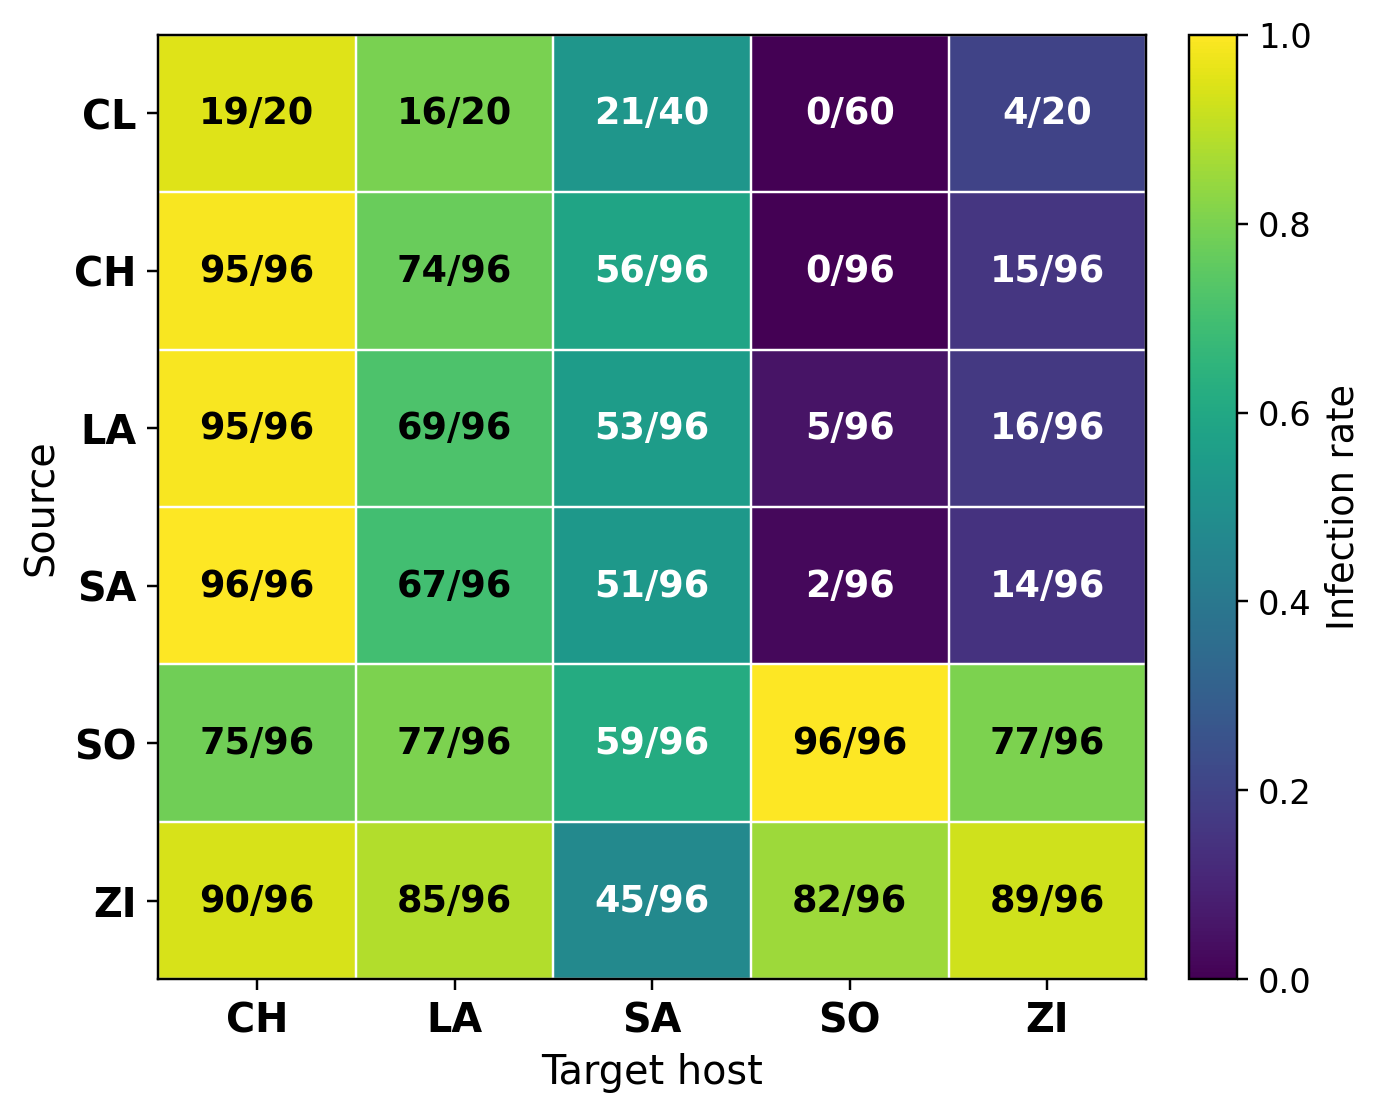

Saved: figures_paper/fig_raw_profile_mds.png


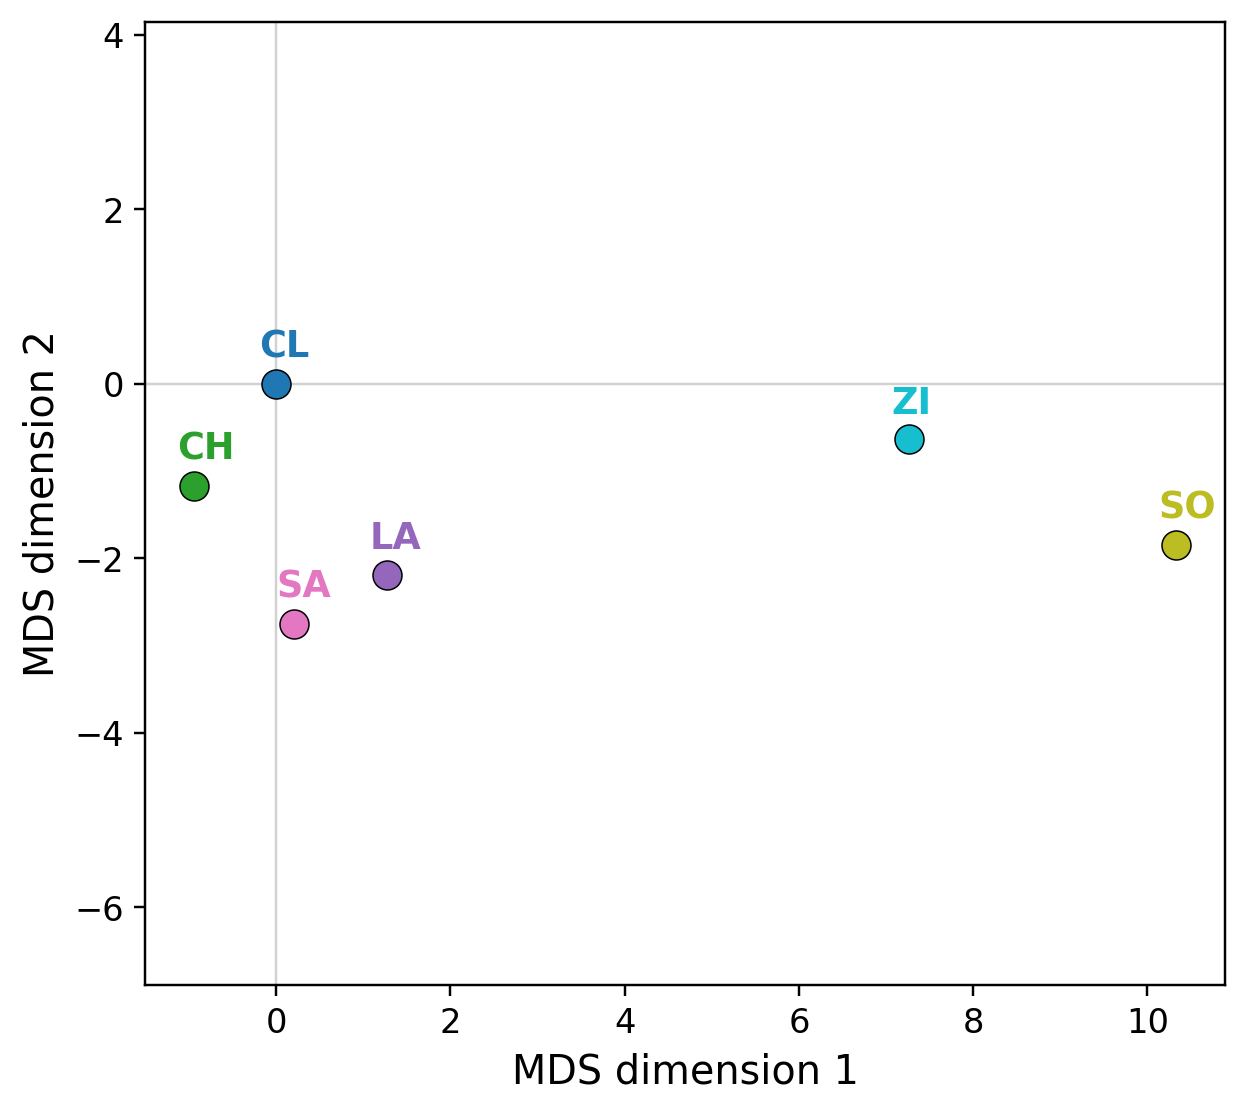

In [17]:
# Separate figures:
# 1. observed infection-success matrix
# 2. descriptive MDS of transformed source profiles

cmap_yellow_red = LinearSegmentedColormap.from_list(
    "yellow_red",
    ["#ffffcc", "#ffeda0", "#feb24c", "#f03b20", "#bd0026"],
    N=256,
)

def readable_text_color(value, cmap, norm, threshold=0.54):
    """
    Choose black or white text from the actual background color.
    Relative luminance formula follows the standard sRGB convention.

    Black text is used on light backgrounds.
    White text is used on dark backgrounds.
    """
    r, g, b, _ = cmap(norm(value))
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return "black" if luminance < threshold else "white"


# ============================================================
# Figure 1: observed infection-success matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.4, 5.2),
    dpi=220,
)

norm = Normalize(vmin=0, vmax=1)

im = ax.imshow(
    rates.values,
    vmin=0,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(np.arange(len(targets)))
ax.set_xticklabels(targets, fontsize=13)

ax.set_yticks(np.arange(len(sources)))
ax.set_yticklabels(sources, fontsize=13)

ax.set_xlabel("Target host", fontsize=13)
ax.set_ylabel("Source", fontsize=13)

# Color tick labels with the same variety colors as in the MCMC notebook.
# Uncomment if you want colored row/column labels.
for tick in ax.get_xticklabels():
    # tick.set_color(label_to_color[tick.get_text()])
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    # tick.set_color(label_to_color[tick.get_text()])
    tick.set_fontweight("bold")

# Cell labels: automatically black/white depending on background luminance.
for i, source in enumerate(sources):
    for j, target in enumerate(targets):
        rate = float(rates.loc[source, target])
        label = f"{success.loc[source, target]}/{trials.loc[source, target]}"

        ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color=readable_text_color(rate, cmap_yellow_red, norm),
        )

# Light grid for readability
ax.set_xticks(np.arange(-0.5, len(targets), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(sources), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Infection rate", fontsize=12)
cbar.ax.tick_params(labelsize=11)

fig.tight_layout()

png_path = os.path.join(OUT, "fig_infection_matrix.png")
pdf_path = os.path.join(OUT, "fig_infection_matrix.pdf")

fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

print("Saved:", png_path)
print("Saved:", pdf_path)

plt.show()


# ============================================================
# Figure 2: classical MDS of transformed source profiles
# ============================================================

fig, ax = plt.subplots(
    figsize=(5.8, 5.2),
    dpi=220,
)

ax.axhline(0, color="0.82", lw=0.8)
ax.axvline(0, color="0.82", lw=0.8)

for source in sources:
    x, y = mds.loc[source, ["MDS1", "MDS2"]]
    col = label_to_color[source]

    ax.scatter(
        x,
        y,
        s=90,
        color=col,
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )

    ax.text(
        x - 0.2,
        y + 0.3,
        source,
        fontsize=12,
        fontweight="bold",
        color=col,
    )

ax.set_xlabel("MDS dimension 1", fontsize=13)
ax.set_ylabel("MDS dimension 2", fontsize=13)

ax.tick_params(axis="both", labelsize=11)
ax.set_aspect("equal", adjustable="datalim")

fig.tight_layout()

png_path = os.path.join(OUT, "fig_raw_profile_mds.png")
#pdf_path = os.path.join(OUT, "fig_raw_profile_mds.pdf")

fig.savefig(png_path, bbox_inches="tight")
#fig.savefig(pdf_path, bbox_inches="tight")

print("Saved:", png_path)
#print("Saved:", pdf_path)

plt.show()